<a href="https://colab.research.google.com/github/huong8a2006-cmd/prog3003-BIT240113-VuThiThuHuong/blob/main/B%C3%A0i_t%E1%BA%ADp_th%E1%BB%B1c_h%C3%A0nh_v%E1%BB%9Bi_Optimization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:

import tensorflow as tf
from tensorflow.keras import datasets
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Dense, Flatten, BatchNormalization, Dropout, Activation
from tensorflow.keras.optimizers import SGD, Adam
import time

(x_train,y_train),(x_test,y_test)=datasets.cifar10.load_data()

x_train=x_train/255.0
x_test=x_test/255.0

def basic_cnn():
    model=Sequential([
        Conv2D(32,(3,3),activation='relu',input_shape=(32,32,3)),
        MaxPooling2D(2,2),
        Conv2D(64,(3,3),activation='relu'),
        MaxPooling2D(2,2),
        Flatten(),
        Dense(128,activation='relu'),
        Dense(10,activation='softmax')
    ])
    return model

def improved_cnn(drop_rate=0.3):
    model=Sequential([
        Conv2D(32,(3,3),padding='same',input_shape=(32,32,3)),
        BatchNormalization(),
        Activation('relu'),
        MaxPooling2D(),
        Dropout(drop_rate),

        Conv2D(64,(3,3),padding='same'),
        BatchNormalization(),
        Activation('relu'),
        MaxPooling2D(),
        Dropout(drop_rate),

        Flatten(),
        Dense(128,activation='relu'),
        Dropout(drop_rate),
        Dense(10,activation='softmax')
    ])
    return model

model=improved_cnn(0.3)

model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

start=time.time()

history=model.fit(
    x_train,
    y_train,
    epochs=20,
    batch_size=64,
    validation_split=0.2
)

train_time=time.time()-start

loss,acc=model.evaluate(x_test,y_test)

print("Test Accuracy:",acc)
print("Test Loss:",loss)
print("Training Time:",train_time)


Epoch 1/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 165s 259ms/step - accuracy: 0.3156 - loss: 1.8292 - val_accuracy: 0.4371 - val_loss: 1.5694
Epoch 2/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 113s 181ms/step - accuracy: 0.4012 - loss: 1.5817 - val_accuracy: 0.3405 - val_loss: 1.8094
Epoch 3/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 140s 178ms/step - accuracy: 0.4349 - loss: 1.4895 - val_accuracy: 0.5694 - val_loss: 1.2569
Epoch 4/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 139s 174ms/step - accuracy: 0.4574 - loss: 1.4369 - val_accuracy: 0.4853 - val_loss: 1.5409
Epoch 5/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 111s 178ms/step - accuracy: 0.4750 - loss: 1.4019 - val_accuracy: 0.5403 - val_loss: 1.3052
Epoch 6/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 139s 174ms/step - accuracy: 0.4858 - loss: 1.3741 - val_accuracy: 0.5621 - val_loss: 1.2647
Epoch 7/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 156s 196ms/step - accuracy: 0.4920 - loss: 1.3526 - val_accuracy: 0.5709 - val_loss: 1.2139
Epoch 8/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 140s 223ms/step - accuracy: 0.5022 -

In [ ]:
import tensorflow as tf
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import *
from tensorflow.keras.optimizers import SGD, Adam
import time

(x_train, y_train), (x_test, y_test) = cifar10.load_data()

x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

def model2():

    model = Sequential([

        Input(shape=(32,32,3)),

        Conv2D(32,(3,3),padding='same'),
        BatchNormalization(),
        Activation('relu'),
        MaxPooling2D(),

        Conv2D(64,(3,3),padding='same'),
        BatchNormalization(),
        Activation('relu'),
        MaxPooling2D(),

        Flatten(),

        Dense(128),
        BatchNormalization(),
        Activation('relu'),

        Dense(10,activation='softmax')
    ])

    return model


model = model2()

model.compile(
    optimizer=SGD(
        learning_rate=0.01,
        momentum=0.9
    ),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

start = time.time()

history2 = model.fit(
    x_train,
    y_train,
    epochs=20,
    batch_size=64,
    validation_split=0.2
)

train_time = time.time() - start

loss, acc = model.evaluate(x_test,y_test)

print("Model 2")
print("Test Accuracy:",acc)
print("Test Loss:",loss)
print("Training Time:",train_time)

Epoch 1/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 123s 191ms/step - accuracy: 0.5568 - loss: 1.2591 - val_accuracy: 0.5847 - val_loss: 1.1770
Epoch 2/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 142s 191ms/step - accuracy: 0.6824 - loss: 0.9038 - val_accuracy: 0.5537 - val_loss: 1.2963
Epoch 3/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 133s 178ms/step - accuracy: 0.7364 - loss: 0.7519 - val_accuracy: 0.5967 - val_loss: 1.2684
Epoch 4/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 141s 176ms/step - accuracy: 0.7812 - loss: 0.6271 - val_accuracy: 0.5607 - val_loss: 1.4295
Epoch 5/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 112s 180ms/step - accuracy: 0.8201 - loss: 0.5205 - val_accuracy: 0.6573 - val_loss: 1.0194
Epoch 6/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 111s 177ms/step - accuracy: 0.8536 - loss: 0.4295 - val_accuracy: 0.6924 - val_loss: 0.9603
Epoch 7/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 139s 173ms/step - accuracy: 0.8839 - loss: 0.3440 - val_accuracy: 0.6720 - val_loss: 1.0899
Epoch 8/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 138s 167ms/step - accuracy: 0.9114 -

In [ ]:
import tensorflow as tf
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import *
from tensorflow.keras.optimizers import SGD, Adam
import time

(x_train, y_train), (x_test, y_test) = cifar10.load_data()

x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

def model3():

    model = Sequential([

        Input(shape=(32,32,3)),

        Conv2D(32,(3,3),padding='same'),
        BatchNormalization(),
        Activation('relu'),
        MaxPooling2D(),
        Dropout(0.3),

        Conv2D(64,(3,3),padding='same'),
        BatchNormalization(),
        Activation('relu'),
        MaxPooling2D(),
        Dropout(0.3),

        Flatten(),

        Dense(128),
        BatchNormalization(),
        Activation('relu'),
        Dropout(0.3),

        Dense(10,activation='softmax')
    ])

    return model


model = model3()

model.compile(
    optimizer=SGD(
        learning_rate=0.01,
        momentum=0.9
    ),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

start = time.time()

history3 = model.fit(
    x_train,
    y_train,
    epochs=20,
    batch_size=64,
    validation_split=0.2
)

train_time = time.time() - start

loss, acc = model.evaluate(x_test,y_test)

print("Model 3")
print("Test Accuracy:",acc)
print("Test Loss:",loss)
print("Training Time:",train_time)

Epoch 1/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 109s 171ms/step - accuracy: 0.4418 - loss: 1.5471 - val_accuracy: 0.3926 - val_loss: 1.8926
Epoch 2/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 143s 173ms/step - accuracy: 0.5455 - loss: 1.2595 - val_accuracy: 0.6014 - val_loss: 1.1364
Epoch 3/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 141s 172ms/step - accuracy: 0.5908 - loss: 1.1396 - val_accuracy: 0.5688 - val_loss: 1.2398
Epoch 4/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 108s 173ms/step - accuracy: 0.6266 - loss: 1.0490 - val_accuracy: 0.6332 - val_loss: 1.0499
Epoch 5/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 149s 184ms/step - accuracy: 0.6499 - loss: 0.9869 - val_accuracy: 0.6241 - val_loss: 1.0349
Epoch 6/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 134s 171ms/step - accuracy: 0.6691 - loss: 0.9390 - val_accuracy: 0.6366 - val_loss: 1.0284
Epoch 7/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 106s 170ms/step - accuracy: 0.6771 - loss: 0.9106 - val_accuracy: 0.6809 - val_loss: 0.8906
Epoch 8/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 140s 168ms/step - accuracy: 0.6883 -

In [ ]:
import tensorflow as tf
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import *
from tensorflow.keras.optimizers import SGD, Adam
import time

(x_train, y_train), (x_test, y_test) = cifar10.load_data()

x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

def model4():

    model = Sequential([

        Input(shape=(32,32,3)),

        Conv2D(32,(3,3),padding='same'),
        BatchNormalization(),
        Activation('relu'),
        MaxPooling2D(),
        Dropout(0.5),

        Conv2D(64,(3,3),padding='same'),
        BatchNormalization(),
        Activation('relu'),
        MaxPooling2D(),
        Dropout(0.5),

        Flatten(),

        Dense(128),
        BatchNormalization(),
        Activation('relu'),
        Dropout(0.5),

        Dense(10,activation='softmax')
    ])

    return model


model = model4()

model.compile(
    optimizer=SGD(
        learning_rate=0.01,
        momentum=0.9
    ),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

start = time.time()

history4 = model.fit(
    x_train,
    y_train,
    epochs=20,
    batch_size=64,
    validation_split=0.2
)

train_time = time.time() - start

loss, acc = model.evaluate(x_test,y_test)

print("Model 4")
print("Test Accuracy:",acc)
print("Test Loss:",loss)
print("Training Time:",train_time)

Epoch 1/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 113s 177ms/step - accuracy: 0.3673 - loss: 1.7518 - val_accuracy: 0.3699 - val_loss: 1.7554
Epoch 2/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 141s 176ms/step - accuracy: 0.4577 - loss: 1.4834 - val_accuracy: 0.5420 - val_loss: 1.3044
Epoch 3/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 111s 178ms/step - accuracy: 0.4941 - loss: 1.3925 - val_accuracy: 0.5488 - val_loss: 1.2723
Epoch 4/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 124s 198ms/step - accuracy: 0.5253 - loss: 1.3189 - val_accuracy: 0.5169 - val_loss: 1.3711
Epoch 5/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 130s 180ms/step - accuracy: 0.5439 - loss: 1.2693 - val_accuracy: 0.4163 - val_loss: 1.7442
Epoch 6/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 111s 178ms/step - accuracy: 0.5611 - loss: 1.2314 - val_accuracy: 0.5476 - val_loss: 1.3210
Epoch 7/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 159s 204ms/step - accuracy: 0.5742 - loss: 1.1902 - val_accuracy: 0.6030 - val_loss: 1.1507
Epoch 8/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 125s 199ms/step - accuracy: 0.5880 -

In [ ]:
import tensorflow as tf
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import *
from tensorflow.keras.optimizers import SGD, Adam
import time

(x_train, y_train), (x_test, y_test) = cifar10.load_data()

x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

def model5():

    model = Sequential([

        Input(shape=(32,32,3)),

        Conv2D(32,(3,3),padding='same'),
        BatchNormalization(),
        Activation('relu'),
        MaxPooling2D(),
        Dropout(0.3),

        Conv2D(64,(3,3),padding='same'),
        BatchNormalization(),
        Activation('relu'),
        MaxPooling2D(),
        Dropout(0.3),

        Flatten(),

        Dense(128),
        BatchNormalization(),
        Activation('relu'),
        Dropout(0.3),

        Dense(10,activation='softmax')
    ])

    return model


model = model5()

model.compile(
    optimizer=Adam(
        learning_rate=0.001
    ),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

start = time.time()

history5 = model.fit(
    x_train,
    y_train,
    epochs=20,
    batch_size=64,
    validation_split=0.2
)

train_time = time.time() - start

loss, acc = model.evaluate(x_test,y_test)

print("Model 5")
print("Test Accuracy:",acc)
print("Test Loss:",loss)
print("Training Time:",train_time)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 2081s 12us/step
Epoch 1/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 106s 165ms/step - accuracy: 0.4695 - loss: 1.4861 - val_accuracy: 0.4951 - val_loss: 1.3572
Epoch 2/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 138s 159ms/step - accuracy: 0.5887 - loss: 1.1581 - val_accuracy: 0.6277 - val_loss: 1.0428
Epoch 3/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 99s 158ms/step - accuracy: 0.6342 - loss: 1.0335 - val_accuracy: 0.6025 - val_loss: 1.0986
Epoch 4/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 147s 166ms/step - accuracy: 0.6583 - loss: 0.9672 - val_accuracy: 0.5022 - val_loss: 1.5580
Epoch 5/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 137s 158ms/step - accuracy: 0.6783 - loss: 0.9110 - val_accuracy: 0.4955 - val_loss: 1.5820
Epoch 6/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 99s 159ms/step - accuracy: 0.6968 - loss: 0.8644 - val_accuracy: 0.6434 - val_loss: 1.0206
Epoch 7/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 146s 165ms/step - accuracy: 0.7134 - loss: 0.8171 - val_accuracy: 0.6763 - val_loss: 0.9193
Epoch 8/20
625/625 ━━

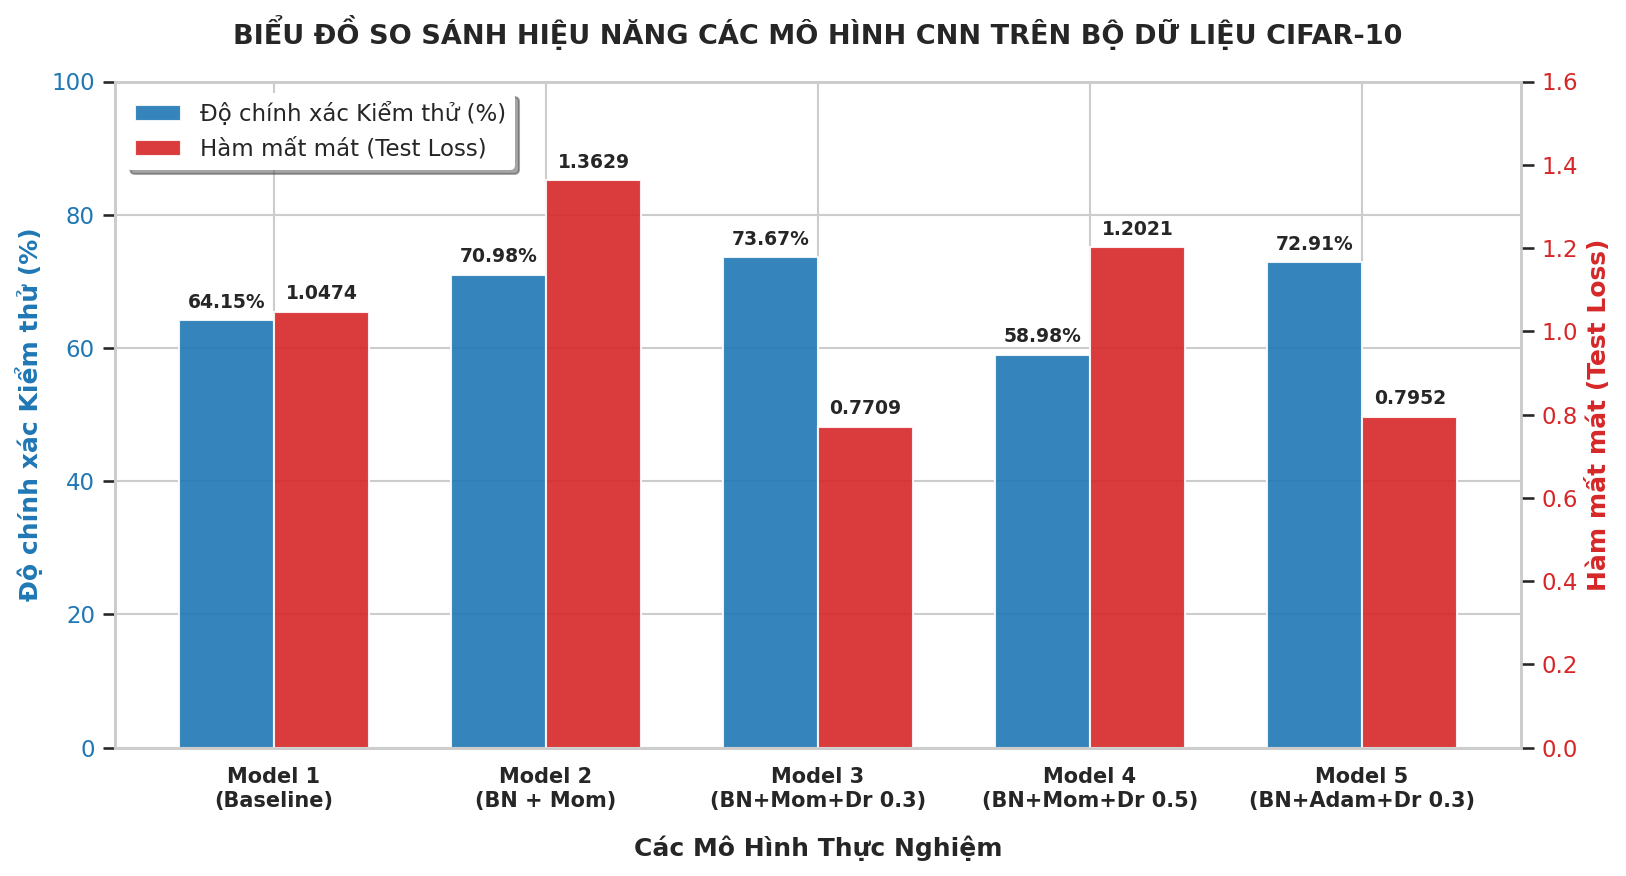

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 1. Thiết lập style nền và cấu hình hiển thị chuyên nghiệp
sns.set_theme(style="whitegrid")
plt.rcParams['font.family'] = 'DejaVu Sans'  # Font mặc định của Colab hỗ trợ tốt tiếng Việt

# 2. Dữ liệu chính xác 100% trích xuất từ nhật ký huấn luyện của bạn
models = [
    'Model 1\n(Baseline)',
    'Model 2\n(BN + Mom)',
    'Model 3\n(BN+Mom+Dr 0.3)',
    'Model 4\n(BN+Mom+Dr 0.5)',
    'Model 5\n(BN+Adam+Dr 0.3)'
]
accuracy = [64.15, 70.98, 73.67, 58.98, 72.91]  # Đơn vị: %
loss = [1.0474, 1.3629, 0.7709, 1.2021, 0.7952]      # Giá trị Loss

x = np.arange(len(models))
width = 0.35  # Độ rộng của mỗi cột dầm

# 3. Khởi tạo đồ thị với độ phân giải cao (DPI=150) để khi chèn vào Docs không bị mờ
fig, ax1 = plt.subplots(figsize=(11, 6), dpi=150)

# --- TRỤC BÊN TRÁI: ĐỘ CHÍNH XÁC (ACCURACY) ---
color_acc = '#1f77b4'  # Màu xanh dương công nghệ
rects1 = ax1.bar(x - width/2, accuracy, width, label='Độ chính xác Kiểm thử (%)', color=color_acc, alpha=0.9)
ax1.set_xlabel('Các Mô Hình Thực Nghiệm', fontweight='bold', fontsize=12, labelpad=12)
ax1.set_ylabel('Độ chính xác Kiểm thử (%)', color=color_acc, fontweight='bold', fontsize=12)
ax1.tick_params(axis='y', labelcolor=color_acc)
ax1.set_ylim(0, 100)  # Giới hạn trục phần trăm từ 0 đến 100%

# --- TRỤC BÊN PHẢI: HÀM MẤT MÁT (TEST LOSS) ---
ax2 = ax1.twinx()  # Tạo trục Y thứ hai đối xứng
color_loss = '#d62728'  # Màu đỏ cảnh báo / hàm phạt
rects2 = ax2.bar(x + width/2, loss, width, label='Hàm mất mát (Test Loss)', color=color_loss, alpha=0.9)
ax2.set_ylabel('Hàm mất mát (Test Loss)', color=color_loss, fontweight='bold', fontsize=12)
ax2.tick_params(axis='y', labelcolor=color_loss)
ax2.set_ylim(0, 1.6)  # Giới hạn trục Loss bao quát được mức cao nhất (1.3629)
ax2.grid(False)       # Tắt grid ẩn của trục 2 để tránh bị đè rối mắt

# 4. Hàm tự động hiển thị nhãn số liệu chính xác lên đầu mỗi cột dầm
def autolabel(rects, ax, is_percent=False):
    for rect in rects:
        height = rect.get_height()
        label_text = f'{height:.2f}%' if is_percent else f'{height:.4f}'
        ax.annotate(label_text,
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 4),  # Đẩy text lên trên đầu cột 4 points
                    textcoords="offset points",
                    ha='center', va='bottom', fontsize=9, fontweight='bold')

autolabel(rects1, ax1, is_percent=True)
autolabel(rects2, ax2, is_percent=False)

# 5. Thiết lập tiêu đề và định dạng tổng thể
plt.title('BIỂU ĐỒ SO SÁNH HIỆU NĂNG CÁC MÔ HÌNH CNN TRÊN BỘ DỮ LIỆU CIFAR-10',
          fontweight='bold', fontsize=13, pad=18)
ax1.set_xticks(x)
ax1.set_xticklabels(models, fontweight='bold', fontsize=10)

# Gộp Legend (Chú thích) của cả 2 trục lại làm một hộp duy nhất đặt ở góc trái
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left',
           frameon=True, facecolor='white', edgecolor='none', shadow=True)

# Tối ưu khoảng cách biên
plt.tight_layout()

# 6. Xuất đồ thị trực quan
plt.show()